# ResNet2D ECG — Georgia ECG Dataset

Modified ResNet-18 on STFT spectrograms `(12, 64, 64)`. Ref: Nature Sci Reports 2024.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pickle, pathlib, time
import torch, torch.nn as nn
import torchvision.models as tv_models
import scipy.signal
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, roc_auc_score, multilabel_confusion_matrix
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", DEVICE)

DATA_DIR = pathlib.Path("../../GeorgiaECG")
CKPT_DIR = pathlib.Path("checkpoints")
CKPT_DIR.mkdir(exist_ok=True)

NORM_CAP = 4000; BATCH_SIZE = 128; LR = 3e-4; WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 50; PATIENCE = 15; WARMUP = 5; NUM_CLASSES = 4
CLASS_NAMES = ["MI", "STTC", "CD", "HYP"]
IMG_SIZE = 64; FS = 100

Device: cuda


## Load Data & Split

In [2]:
with open(DATA_DIR/"X_georgia.pickle","rb") as f: X_all = pickle.load(f)
with open(DATA_DIR/"y_georgia.pickle","rb") as f: y_all = pickle.load(f)
print(f"X: {X_all.shape}, y: {y_all.shape}")

rng = np.random.default_rng(SEED)
norm_idx    = np.where(y_all.sum(axis=1)==0)[0]
disease_idx = np.where(y_all.sum(axis=1)>0)[0]
if len(norm_idx)>NORM_CAP: norm_idx = rng.choice(norm_idx,NORM_CAP,replace=False)
keep_idx = np.concatenate([norm_idx,disease_idx]); rng.shuffle(keep_idx)
X_all,y_all = X_all[keep_idx],y_all[keep_idx]

strat_cols = np.concatenate([y_all,(y_all.sum(1)==0).astype(np.float32)[:,None]],axis=1)
msss1 = MultilabelStratifiedShuffleSplit(n_splits=1,test_size=0.15,random_state=SEED)
tr_val_idx,te_idx = next(msss1.split(X_all,strat_cols))
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1,test_size=0.176,random_state=SEED)
tr_idx,val_idx = next(msss2.split(X_all[tr_val_idx],strat_cols[tr_val_idx]))
tr_idx=tr_val_idx[tr_idx]; val_idx=tr_val_idx[val_idx]

X_train,y_train = X_all[tr_idx],y_all[tr_idx]
X_val,y_val     = X_all[val_idx],y_all[val_idx]
X_test,y_test   = X_all[te_idx],y_all[te_idx]
print(f"Train {len(tr_idx)} | Val {len(val_idx)} | Test {len(te_idx)}")

X: (10344, 12, 1000), y: (10344, 4)
Train 7230 | Val 1559 | Test 1555


## STFT Spectrogram Dataset

In [3]:
def ecg_to_spectrogram(signal, fs=FS, img_size=IMG_SIZE):
    """signal: (12, T) → spectrogram: (12, img_size, img_size)"""
    specs = []
    for ch in range(signal.shape[0]):
        _, _, Zxx = scipy.signal.stft(signal[ch], fs=fs, nperseg=64, noverlap=48)
        mag = np.log1p(np.abs(Zxx)).astype(np.float32)
        mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)
        img = np.array(Image.fromarray((mag*255).astype(np.uint8)).resize((img_size,img_size), Image.BILINEAR), dtype=np.float32) / 255.0
        specs.append(img)
    return np.stack(specs, axis=0)  # (12, H, W)

class ECGSpectrogramDataset(Dataset):
    def __init__(self, X, y):
        self.X = X; self.y = torch.from_numpy(y).float()
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        spec = ecg_to_spectrogram(self.X[i])
        return torch.from_numpy(spec), self.y[i]

_kw = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
tr_loader  = DataLoader(ECGSpectrogramDataset(X_train,y_train), shuffle=True,  **_kw)
val_loader = DataLoader(ECGSpectrogramDataset(X_val,  y_val),   shuffle=False, **_kw)
te_loader  = DataLoader(ECGSpectrogramDataset(X_test, y_test),  shuffle=False, **_kw)

## Model: Modified ResNet-18

In [4]:
class ResNet2D_ECG(nn.Module):
    def __init__(self, n_classes=NUM_CLASSES):
        super().__init__()
        resnet = tv_models.resnet18(weights=None)
        resnet.conv1 = nn.Conv2d(12, 64, kernel_size=7, stride=2, padding=3, bias=False)
        resnet.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(512, n_classes))
        self.model = resnet
    def forward(self, x): return self.model(x)

model = ResNet2D_ECG().to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Parameters: 11,206,788


## Loss, Optimizer, Scheduler

In [5]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha=alpha; self.gamma=gamma
        self.bce=nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction="none")
    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        p_t = torch.sigmoid(logits)*targets + (1-torch.sigmoid(logits))*(1-targets)
        return (self.alpha*(1-p_t)**self.gamma * bce).mean()

pos_w = torch.tensor([(y_all.shape[0]-y_all[:,i].sum())/(y_all[:,i].sum()+1e-6) for i in range(NUM_CLASSES)],dtype=torch.float32).to(DEVICE)
criterion = FocalLoss(alpha=0.25, gamma=2.0, pos_weight=pos_w)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

## Training

In [6]:
def run_epoch(loader, mdl, crit, opt=None):
    training = opt is not None
    mdl.train() if training else mdl.eval()
    total_loss, all_probs, all_tgts = 0., [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = mdl(xb); loss = crit(logits, yb)
            if training:
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(mdl.parameters(), 1.0); opt.step()
            total_loss += loss.item()*len(xb)
            all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_tgts.append(yb.detach().cpu().numpy())
    return total_loss/len(loader.dataset), np.concatenate(all_probs), np.concatenate(all_tgts)

In [7]:
train_losses,val_losses,val_f1s = [],[],[]
best_val_f1,best_state,best_ep,no_improve = 0.,None,0,0

for epoch in range(1,MAX_EPOCHS+1):
    t0=time.time()
    tr_loss,_,_ = run_epoch(tr_loader,model,criterion,optimizer)
    val_loss,val_probs,val_tgts = run_epoch(val_loader,model,criterion)
    val_f1 = f1_score(val_tgts,(val_probs>=0.5).astype(int),average="macro",zero_division=0)
    scheduler.step(val_loss)
    train_losses.append(tr_loss); val_losses.append(val_loss); val_f1s.append(val_f1)
    marker=""
    if epoch>WARMUP and val_f1>best_val_f1:
        best_val_f1=val_f1; best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
        best_ep=epoch; no_improve=0; marker=" ✓"
    elif epoch>WARMUP: no_improve+=1
    print(f"Ep {epoch:3d} | tr {tr_loss:.4f} | val {val_loss:.4f} | F1 {val_f1:.4f} | {time.time()-t0:.1f}s{marker}")
    if epoch>WARMUP and no_improve>=PATIENCE: print("Early stopping."); break

torch.save(best_state, CKPT_DIR/"best_model.pt")
print(f"Best epoch {best_ep}, val F1 {best_val_f1:.4f}")

Ep   1 | tr 0.0714 | val 0.0621 | F1 0.3401 | 22.0s
Ep   2 | tr 0.0604 | val 0.0587 | F1 0.4084 | 21.5s
Ep   3 | tr 0.0547 | val 0.0570 | F1 0.4704 | 21.4s
Ep   4 | tr 0.0507 | val 0.0599 | F1 0.4769 | 21.4s
Ep   5 | tr 0.0478 | val 0.0606 | F1 0.5056 | 21.4s
Ep   6 | tr 0.0443 | val 0.0670 | F1 0.4929 | 21.4s ✓
Ep   7 | tr 0.0431 | val 0.0679 | F1 0.5050 | 21.4s ✓
Ep   8 | tr 0.0376 | val 0.0813 | F1 0.4985 | 21.5s
Ep   9 | tr 0.0361 | val 0.0892 | F1 0.4883 | 21.5s
Ep  10 | tr 0.0269 | val 0.1003 | F1 0.4911 | 21.5s
Ep  11 | tr 0.0179 | val 0.1290 | F1 0.4671 | 21.6s
Ep  12 | tr 0.0110 | val 0.1721 | F1 0.4849 | 21.5s
Ep  13 | tr 0.0087 | val 0.1930 | F1 0.4682 | 21.5s
Ep  14 | tr 0.0063 | val 0.2031 | F1 0.4645 | 21.5s
Ep  15 | tr 0.0053 | val 0.2154 | F1 0.4795 | 21.5s
Ep  16 | tr 0.0028 | val 0.2276 | F1 0.4655 | 21.5s
Ep  17 | tr 0.0009 | val 0.2359 | F1 0.4584 | 21.5s
Ep  18 | tr 0.0004 | val 0.2434 | F1 0.4688 | 21.5s
Ep  19 | tr 0.0003 | val 0.2468 | F1 0.4664 | 21.5s
Ep  20 |

## Training Curves

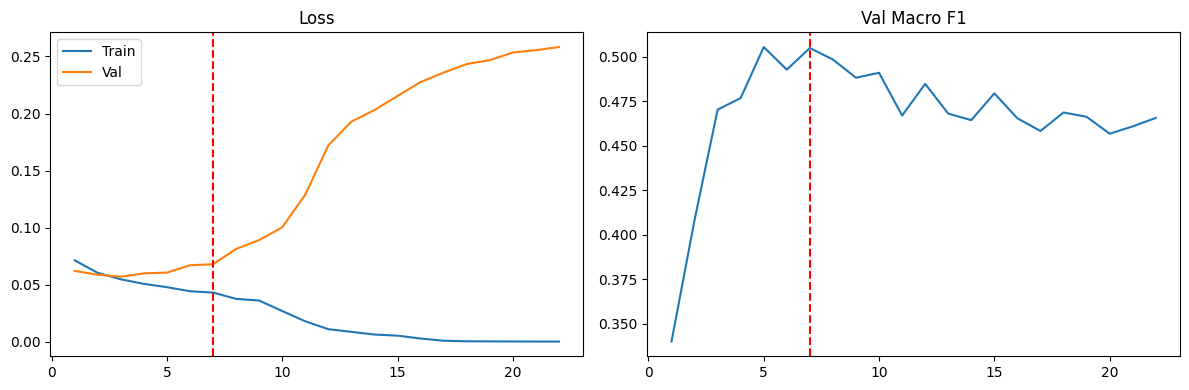

In [8]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4))
eps=range(1,len(train_losses)+1)
ax1.plot(eps,train_losses,label="Train"); ax1.plot(eps,val_losses,label="Val")
ax1.axvline(best_ep,color="r",ls="--"); ax1.legend(); ax1.set_title("Loss")
ax2.plot(eps,val_f1s); ax2.axvline(best_ep,color="r",ls="--"); ax2.set_title("Val Macro F1")
plt.tight_layout(); plt.savefig(CKPT_DIR/"training_curves.png",dpi=100); plt.show()

## Test Evaluation

In [9]:
model.load_state_dict(best_state); model_trained=model
_,val_probs_tune,val_tgts_tune = run_epoch(val_loader,model_trained,criterion)
_,test_probs,test_tgts         = run_epoch(te_loader, model_trained,criterion)
cv_test_probs=val_probs_tune; cv_test_targets=val_tgts_tune

## Threshold Tuning (Val Set)

In [10]:
best_thresholds=[]
for i,name in enumerate(CLASS_NAMES):
    best_t,best_f=0.5,0.
    for t in np.arange(0.1,0.9,0.02):
        f=f1_score(cv_test_targets[:,i],(cv_test_probs[:,i]>=t).astype(int),zero_division=0)
        if f>best_f: best_f=f; best_t=t
    best_thresholds.append(best_t); print(f"  {name}: thresh={best_t:.2f} val_F1={best_f:.4f}")
tuned_arr=np.array(best_thresholds)

  MI: thresh=0.48 val_F1=0.2268
  STTC: thresh=0.52 val_F1=0.6315
  CD: thresh=0.44 val_F1=0.6415
  HYP: thresh=0.48 val_F1=0.5878


In [11]:
preds_def=(test_probs>=0.5).astype(int); preds_tuned=(test_probs>=tuned_arr).astype(int)
print(f"{'Class':<8} {'F1_def':>8} {'F1_tuned':>10}")
for i,name in enumerate(CLASS_NAMES):
    print(f"{name:<8} {f1_score(test_tgts[:,i],preds_def[:,i],zero_division=0):8.4f} {f1_score(test_tgts[:,i],preds_tuned[:,i],zero_division=0):10.4f}")
f1d=f1_score(test_tgts,preds_def,average="macro",zero_division=0)
f1t=f1_score(test_tgts,preds_tuned,average="macro",zero_division=0)
print(f"{'Macro':<8} {f1d:8.4f} {f1t:10.4f}")
try: print(f"AUC: {roc_auc_score(test_tgts,test_probs,average='macro'):.4f}")
except: pass

Class      F1_def   F1_tuned
MI         0.2361     0.2400
STTC       0.6437     0.6376
CD         0.6091     0.6461
HYP        0.5723     0.5684
Macro      0.5153     0.5230
AUC: 0.7340


## Confusion Matrices

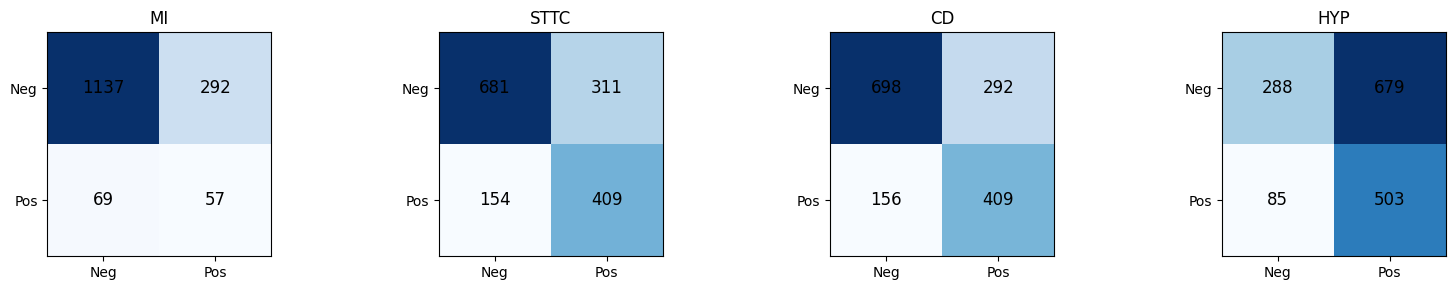

In [12]:
mcm=multilabel_confusion_matrix(test_tgts.astype(int),preds_tuned)
fig,axes=plt.subplots(1,4,figsize=(16,3))
for i,(ax,name) in enumerate(zip(axes,CLASS_NAMES)):
    ax.imshow(mcm[i],cmap="Blues"); ax.set_title(name)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Neg","Pos"]); ax.set_yticklabels(["Neg","Pos"])
    for r in range(2):
        for c in range(2): ax.text(c,r,mcm[i][r,c],ha="center",va="center",fontsize=12)
plt.tight_layout(); plt.savefig(CKPT_DIR/"confusion_matrices.png",dpi=100); plt.show()

## GradCAM Visualization

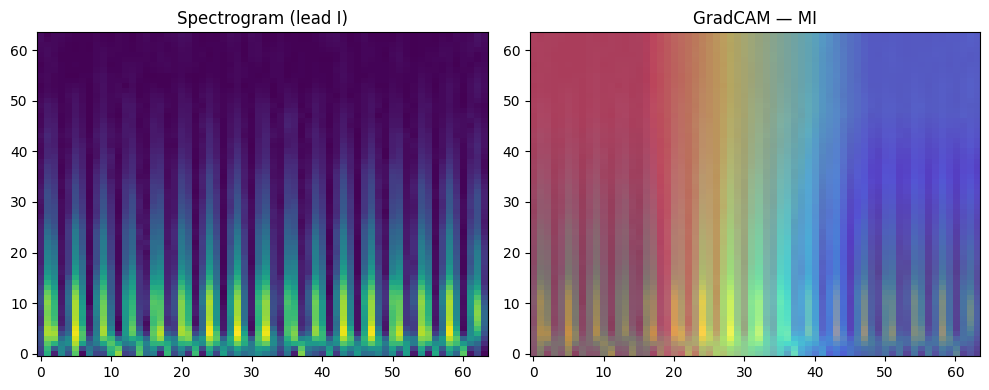

In [13]:
from torch.nn import functional as F

def gradcam_2d(mdl, spec_tensor, class_idx):
    """spec_tensor: (1,12,H,W) on DEVICE. Returns (H,W) heatmap."""
    mdl.eval()
    target_layer = mdl.model.layer4[-1].conv2
    feats, grads = [], []
    h1 = target_layer.register_forward_hook(lambda m,i,o: feats.append(o))
    h2 = target_layer.register_backward_hook(lambda m,gi,go: grads.append(go[0]))
    out = mdl(spec_tensor)
    mdl.zero_grad(); out[0, class_idx].backward()
    h1.remove(); h2.remove()
    alpha = grads[0].mean(dim=[2,3], keepdim=True)
    cam = F.relu((alpha*feats[0]).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=spec_tensor.shape[2:], mode="bilinear", align_corners=False)
    cam = cam[0,0].detach().cpu().numpy()
    cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
    return cam

# Visualize for first MI sample
mi_idx = np.where(test_tgts[:,0]==1)[0][0]
sample = ecg_to_spectrogram(X_test[mi_idx])
inp = torch.from_numpy(sample).unsqueeze(0).to(DEVICE)
cam = gradcam_2d(model_trained, inp, 0)

fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].imshow(sample[0],cmap="viridis",origin="lower",aspect="auto"); axes[0].set_title("Spectrogram (lead I)")
axes[1].imshow(sample[0],cmap="viridis",origin="lower",aspect="auto",alpha=0.6)
axes[1].imshow(cam,cmap="jet",origin="lower",aspect="auto",alpha=0.4); axes[1].set_title("GradCAM — MI")
plt.tight_layout(); plt.show()